In [ ]:
from ihp import PDK
from ihp.cells.inductors import inductor2
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
#yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

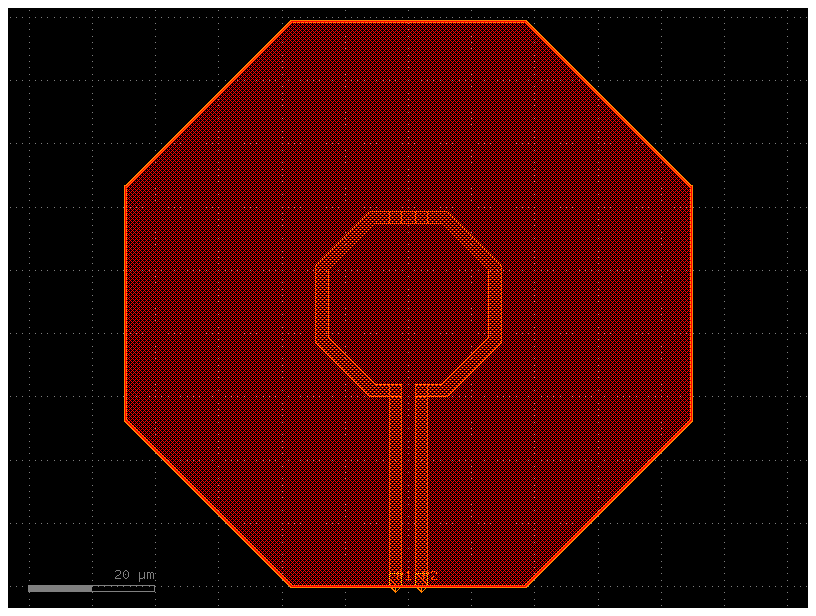

In [33]:
c = inductor2()

cc = c.copy()
cc.flatten()

c.draw_ports()
c.plot()

In [34]:
cc.ports

["Port(self.name='P1', self.width=2000, trans=r270 *1 -2.05,0, layer=TopMetal2pin (134/2), port_type=electrical)", "Port(self.name='P2', self.width=2000, trans=r270 *1 2.05,0, layer=TopMetal2pin (134/2), port_type=electrical)"]

In [35]:
sim = DrivenSim()
sim.set_output_dir("../palace-sim-inductor2")
sim.set_geometry(cc)

sim.set_stack(yaml_path=yaml_file)

sim.add_port("P1",layer="topmetal2")
sim.add_port("P2",layer="topmetal2")

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [36]:
sim.mesh(preset="fine")

Mesh Summary
Dimensions: 229.4 x 259.4 x 518.3 µm
Nodes:      1,575
Elements:   11,946
Tetrahedra: 8,582
Edge length: 0.40 - 144.25 µm
Quality:    0.580 (min: 0.002)
SICN:       0.616 (all valid)
----------------------------------------
Volumes (5):
  - air [1]
  - passive [2]
  - SiO2 [3]
  - silicon [4]
  - airbox [5]
Surfaces (5):
  - topmetal2_xy [6]
  - topmetal2_z [7]
  - P1 [8]
  - P2 [9]
  - Absorbing_boundary [10]
----------------------------------------
Mesh:   ../palace-sim-inductor2/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 09:42:06.288 ( 177.544s) [    7D35E0AD9080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 09:42:06.297 ( 177.553s) [    7D35E0AD9080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 09:42:06.323 ( 177.579s) [    7D35E0AD9080]vt

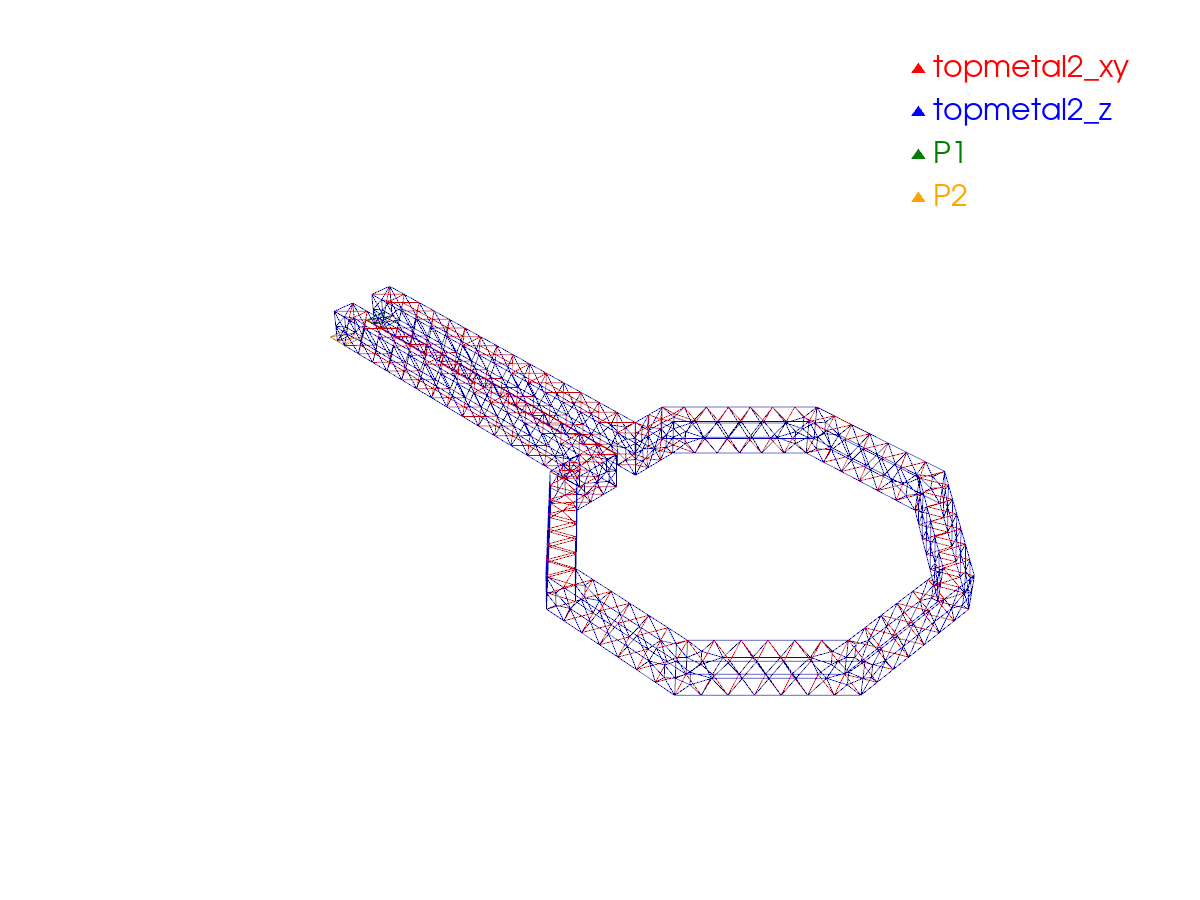

In [37]:
sim.plot_mesh(show_groups=["metal","P"],interactive=False)